<a href="https://colab.research.google.com/github/Chanoknan-P/how-to-select-variables-robustly-in-a-scoring-model/blob/main/Bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/project data mining/bank/bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
# เรียกดู missing value
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
# ดู column
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [ ]:
# กำหนดตัวแปร
continuous_vars = ['age', 'balance', 'campaign', 'pdays', 'previous']
categorical_vars = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']

target = 'deposit'

In [ ]:
# สร้างตัวแปร categorical ใหม่ก่อนแตะ pdays เดิม
df['was_contacted_before'] = df['pdays'].apply(lambda x: 'no' if x == -1 else 'yes')

# แทนที่ -1 ด้วย NaN ใน pdays (จะได้ไม่ปนกับค่าจริง)
df['pdays'] = df['pdays'].replace(-1, np.nan)

# เพิ่ม was_contacted_before เข้า categorical_vars
categorical_vars = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome', 'was_contacted_before']

# continuous_vars ยังมี pdays อยู่ได้ แต่ตอนทำ Kruskal-Wallis/Spearman
# แถวที่เป็น NaN จะถูก dropna() ออกไปเอง (ฟังก์ชันเดิมมี .dropna() อยู่แล้วทุกจุด)
continuous_vars = ['age', 'balance', 'campaign', 'pdays', 'previous']

In [ ]:
# 1. แปลงทุกคอลัมน์ใน continuous_vars ให้เป็น numeric (หากเจอช่องว่างหรือข้อความจะแปลงเป็น NaN)
for col in continuous_vars:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# (Optional) หากมีค่า NaN เกิดขึ้นจากการแปลง สามารถแทนที่ด้วยค่า Median ได้
# df[continuous_vars] = df[continuous_vars].fillna(df[continuous_vars].median())

# 2. จัดการ Outlier ด้วยวิธี IQR Capping
for col in continuous_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping Outliers (ใช้วิธี np.clip จะสะอาดและเร็วขึ้น)
    df[col] = np.clip(df[col], lower_bound, upper_bound)

# แสดงข้อมูลสถิติเชิงพรรณนาอีกครั้งเพื่อดูผลลัพธ์
df[continuous_vars].describe()

,age,balance,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,2838.000000,11162.000000
mean,41.152347,1117.352804,2.238577,203.093376,0.485397
std,11.659113,1349.670734,1.521158,115.450365,0.892563
min,18.000000,-2257.000000,1.000000,1.000000,0.000000
25%,32.000000,122.000000,1.000000,98.000000,0.000000
50%,39.000000,550.000000,2.000000,182.000000,0.000000
75%,49.000000,1708.000000,3.000000,286.000000,1.000000
max,74.500000,4087.000000,6.000000,568.000000,2.500000


In [ ]:
# เช็คค่าดั้งเดิมว่าเขียนยังไง (ป้องกันการพิมพ์ผิด)
print("ค่าดั้งเดิม:", df['deposit'].unique())

# แปลงค่าแบบปลอดภัยด้วย .replace()
df['deposit'] = df['deposit'].replace({'no': 0, 'yes': 1})

# เช็คจำนวน Missing Values (ต้องได้ 0)
print("จำนวน Null ใน deposit:", df['deposit'].isnull().sum())

ค่าดั้งเดิม: ['yes' 'no']
จำนวน Null ใน deposit: 0


/tmp/ipykernel_914/3021601493.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['deposit'] = df['deposit'].replace({'no': 0, 'yes': 1})


In [ ]:
# เช็ครายชื่อคอลัมน์ทั้งหมดก่อนว่ามีคำว่า 'deposit' หรือ 'y'
print("คอลัมน์ทั้งหมด:", df.columns.tolist())

# เช็คค่าดั้งเดิมทันทีหลังจากโหลด
target_col = 'deposit' if 'deposit' in df.columns else 'y'
print(f"ค่าดั้งเดิมในคอลัมน์ {target_col}:", df[target_col].unique())

# แปลงค่า
df[target_col] = df[target_col].replace({'no': 0, 'yes': 1})

# ตรวจสอบผลลัพธ์
print(df[target_col].value_counts())

คอลัมน์ทั้งหมด: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit', 'was_contacted_before']
ค่าดั้งเดิมในคอลัมน์ deposit: [1 0]
deposit
0    5873
1    5289
Name: count, dtype: int64


บทความที่ 2 Building Robust Credit Scoring Models with Python

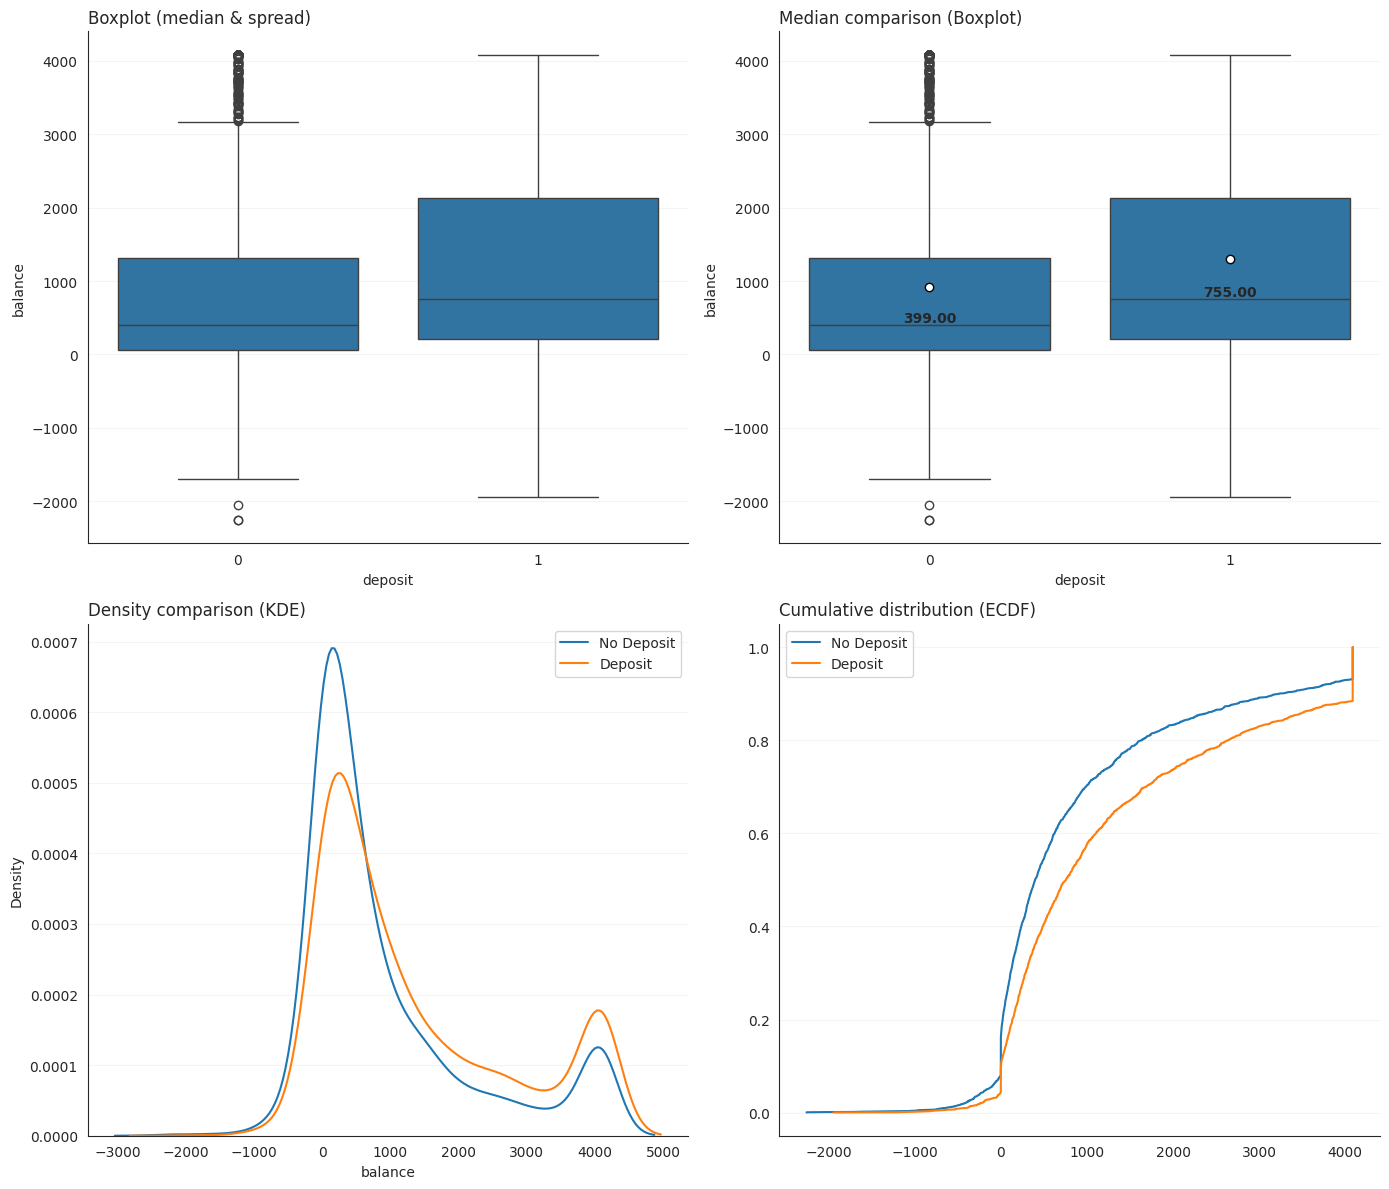

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# เปรียบเทียบ continuous variable กับ categorical variable
def plot_continuous_vs_categorical(
    df,
    continuous_var,
    categorical_var,
    category_labels=None,
    figsize=(12, 10),
    sample=None
):
    """
     เปรียบเทียบตัวแปรที่เป็นตัวเลข ระหว่างกลุ่มต่าง ๆ โดยใช้ boxplot, KDE, and ECDFแบบ
    และจัดกราฟเป็นช่อง 2×2
    """

    sns.set_style("white")

    data = df[[continuous_var, categorical_var]].dropna().copy()

    # การสุ่มเลือกข้อมูลบางส่วนมาใช้
    if sample:
        data = data.sample(sample, random_state=42)

    categories = sorted(data[categorical_var].unique())

    # การเปลี่ยนชื่อ labels
    if category_labels:
        labels = [category_labels.get(cat, str(cat)) for cat in categories]
    else:
        labels = [str(cat) for cat in categories]

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # 1. Boxplot
    sns.boxplot(
        data=data,
        x=categorical_var,
        y=continuous_var,
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Boxplot (median & spread)", loc="left")

    # 2. Boxplot สำหรับเปรียบเทียบค่ามัธยฐาน
    sns.boxplot(
        data=data,
        x=categorical_var,
        y=continuous_var,
        ax=axes[0, 1],
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 6
        }
    )

    axes[0, 1].set_title("Median comparison (Boxplot)", loc="left")
    medians = data.groupby(categorical_var)[continuous_var].median()

    for i, cat in enumerate(categories):
        axes[0, 1].text(
            i,
            medians[cat],
            f"{medians[cat]:.2f}",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    # 3. KDE กราฟเส้นโค้งที่แสดงการกระจายของข้อมูล
    for cat, label in zip(categories, labels):
        subset = data[data[categorical_var] == cat][continuous_var]
        sns.kdeplot(
            subset,
            ax=axes[1, 0],
            label=label
        )
    axes[1, 0].set_title("Density comparison (KDE)", loc="left")
    axes[1, 0].legend()

    # 4. ECDF
    for cat, label in zip(categories, labels):
        subset = np.sort(data[data[categorical_var] == cat][continuous_var])
        y = np.arange(1, len(subset) + 1) / len(subset)
        axes[1, 1].plot(subset, y, label=label)
    axes[1, 1].set_title("Cumulative distribution (ECDF)", loc="left")
    axes[1, 1].legend()

    # ทำเป็นรูปแบบกราฟที่สะอาดและเรียบง่าย
    for ax in axes.flat:
        sns.despine(ax=ax)
        ax.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_continuous_vs_categorical(
    df=df,
    continuous_var="balance",
    categorical_var="deposit",
    category_labels={0: "No Deposit", 1: "Deposit"},
    figsize=(14, 12),
    sample=5000
)

Chi-Square Test: deposit vs loan
Chi2 Statistic : 135.8322
p-value        : 2.1713e-31
Degrees of Freedom: 1
Cramér's V     : 0.1103
Result         : Significant (มีความสัมพันธ์กันอย่างมีนัยสำคัญทางสถิติ p < 0.05)


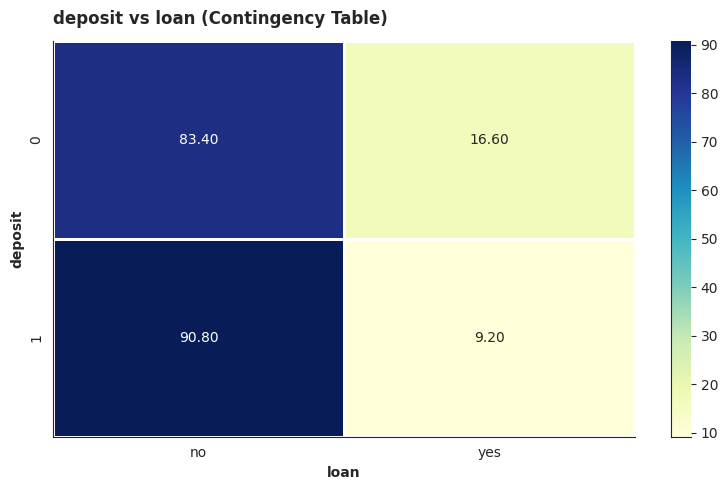

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def contingency_analysis(
    df,
    var1,
    var2,
    normalize=None,   # None, "index", "columns", "all"
    plot=True,
    figsize=(8, 5)
):
    """
    Function to compute and visualize contingency table
    + Chi-square test + Cramér's V.
    """
    # 1. ตารางแจกแจงความถี่แบบไขว้ / ตารางไขว้
    table = pd.crosstab(df[var1], df[var2], margins=False)

    # 2. ตารางที่แปลงจากจำนวนเป็นสัดส่วน/เปอร์เซ็นต์
    if normalize:
        table_norm = pd.crosstab(df[var1], df[var2], normalize=normalize, margins=False).round(3) * 100
    else:
        table_norm = None

    # 3. Chi-square Test & Cramér's V Calculation
    chi2, p_val, dof, expected = chi2_contingency(table)

    n = table.sum().sum()
    min_dim = min(table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    # แสดงผลลัพธ์ทางสถิติ
    print("=" * 45)
    print(f"Chi-Square Test: {var1} vs {var2}")
    print("=" * 45)
    print(f"Chi2 Statistic : {chi2:.4f}")
    print(f"p-value        : {p_val:.4e}")
    print(f"Degrees of Freedom: {dof}")
    print(f"Cramér's V     : {cramers_v:.4f}")

    # การแปลผล
    if p_val < 0.05:
        print("Result         : Significant (มีความสัมพันธ์กันอย่างมีนัยสำคัญทางสถิติ p < 0.05)")
    else:
        print("Result         : Not Significant (ไม่มีความสัมพันธ์กันอย่างมีนัยสำคัญทางสถิติ)")
    print("=" * 45)

    #  4. กราฟ Heatmap
    if plot:
        sns.set_style("white")
        plt.figure(figsize=figsize)
        data_to_plot = table_norm if table_norm is not None else table

        sns.heatmap(
            data_to_plot,
            annot=True,
            fmt=".2f" if normalize else "d",
            cmap="YlGnBu",
            linewidths=1,
            cbar=True
        )
        plt.title(f"{var1} vs {var2} (Contingency Table)", loc="left", weight="bold", pad=12)
        plt.xlabel(var2, weight="bold")
        plt.ylabel(var1, weight="bold")
        sns.despine()
        plt.tight_layout()
        plt.show()


contingency_analysis(df, 'deposit', 'loan', normalize='index')

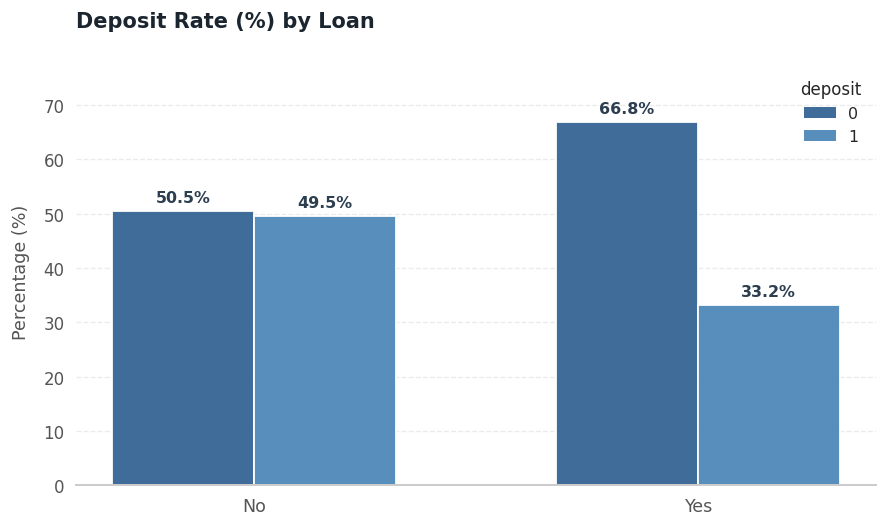

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_grouped_bar(df, cat_var, subcat_var,
                     normalize="index", title=""):
    # คำนวณ Crosstab
    ct = pd.crosstab(df[subcat_var], df[cat_var], normalize=normalize) * 100
    modalities = ct.index.tolist()
    categories = ct.columns.tolist()
    n_mod = len(modalities)
    n_cat = len(categories)
    x = np.arange(n_mod)
    width = 0.32


    colors = ['#1f77b4', '#aec7e8'] if n_cat <= 2 else plt.cm.YlGnBu(np.linspace(0.4, 0.85, n_cat))
    colors = ['#2b5c8f', '#4682b4'] if n_cat == 2 else colors

    fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=120)

    # วาด Grouped Bar
    for i, (cat, color) in enumerate(zip(categories, colors)):
        offset = (i - n_cat / 2 + 0.5) * width
        rects = ax.bar(x + offset, ct[cat], width=width, color=color,
                       label=str(cat), edgecolor='white', linewidth=1.2, alpha=0.9)


        for j, val in enumerate(ct[cat]):
            ax.text(x[j] + offset, val + 1.2, f"{val:.1f}%",
                    ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#2c3e50')

    # การจัดสไตล์ของกราฟ
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['bottom'].set_linewidth(1.2)

    ax.yaxis.grid(True, color='#e9ecef', linestyle='--', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    max_val = ct.values.max()
    ax.set_ylim(0, max_val + 12)

    ax.set_xticks(x)
    ax.set_xticklabels([str(m).title() for m in modalities], fontsize=10.5, color='#333333', fontweight='medium')
    ax.set_ylabel("Percentage (%)" if normalize else "Count", fontsize=10.5, color='#555555', labelpad=8)
    ax.tick_params(left=False, bottom=False, colors='#555555')

    # Legend แบบมินิมอล วางไว้มุมขวาบน
    handles = [mpatches.Patch(facecolor=c, edgecolor='none', label=str(l), alpha=0.9)
               for c, l in zip(colors, categories)]
    ax.legend(handles=handles, title=cat_var, frameon=False,
              fontsize=9.5, title_fontsize=10, loc='upper right', bbox_to_anchor=(1, 0.98))

    # ชื่อกราฟ
    ax.set_title(title, fontsize=12.5, fontweight='bold', color='#1a252f', pad=18, loc='left')

    plt.tight_layout()
    plt.savefig("grouped_bar_styled.png", dpi=300, bbox_inches='tight')
    plt.show()

#  เรียกใช้งาน
plot_grouped_bar(
    df=df,
    cat_var="deposit",     # หรือ "Churn"
    subcat_var="loan",
    normalize="index",
    title="Deposit Rate (%) by Loan"
)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal

def correlation_quanti_def_KW(database: pd.DataFrame,
                             continuous_vars: list,
                             target: str) -> pd.DataFrame:
    """
    Compute Kruskal-Wallis test p-values between continuous variables
    and a categorical target (e.g., 'deposit').
    """
    results = []

    for var in continuous_vars:
        # ลบข้อมูลที่เป็น NA ของตัวแปรที่กำลังวิเคราะห์และตัวแปรเป้าหมายออก
        df_temp = database[[var, target]].dropna()

        # แบ่งค่าของตัวแปรตามกลุ่มของตัวแปรเป้าหมาย
        groups = [
            group[var].values
            for _, group in df_temp.groupby(target)
        ]

        # Kruskal-Wallis แบ่งค่าของตัวแปรตามกลุ่มของตัวแปรเป้าหมาย
        if len(groups) < 2:
            p_value = None
            stat = None
        else:
            try:
                stat, p_value = kruskal(*groups)
            except ValueError:
                # จัดการกรณีที่อาจทำให้โค้ดมีปัญหา เช่น ทำให้ค่าทุกตัวเท่ากัน
                p_value = None
                stat = None

        # คำนวณขนาดของผลกระทบ (Eta-Squared) ซึ่งเป็นตัวเลือกเพิ่มเติมเพื่อช่วยในการตีความผล
        results.append(
            {
                "variable": var,
                "stats_kw": stat,
                "p_value": p_value,
                "significant": "Yes (p < 0.05)" if (p_value is not None and p_value < 0.05) else "No"
            }
        )

    return pd.DataFrame(results).sort_values(by="p_value")

# 1. กำหนดรายชื่อคอลัมน์เชิงตัวเลขสำหรับ Bank Marketing Dataset
continuous_vars = [
    'age',
    'balance',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'default'
]

# กรองเฉพาะคอลัมน์ตัวเลขที่มีอยู่จริงใน df เพื่อป้องกัน KeyError
existing_cont_vars = [col for col in continuous_vars if col in df.columns]

# 2. กำหนด Target เป็น 'deposit'
target = "deposit"

# 3. รันฟังก์ชัน
result_kw = correlation_quanti_def_KW(
    database=df,
    continuous_vars=existing_cont_vars,
    target=target
)

# แสดงผลลัพธ์
print(result_kw)

# 4. บันทึกผลลัพธ์ลงไฟล์ Excel
result_kw.to_excel("correlations_kw_deposit.xlsx", index=False)
print("\nบันทึกไฟล์ 'correlations_kw_deposit.xlsx' เรียบร้อยแล้ว")

   variable     stats_kw        p_value     significant
2  duration  3109.167830   0.000000e+00  Yes (p < 0.05)
5  previous   591.737938  1.049262e-130  Yes (p < 0.05)
1   balance   277.887908   2.167024e-62  Yes (p < 0.05)
3  campaign   177.322531   1.862277e-40  Yes (p < 0.05)
4     pdays    98.073276   4.031835e-23  Yes (p < 0.05)
6   default    18.469998   1.726001e-05  Yes (p < 0.05)
0       age     1.649791   1.989873e-01              No

บันทึกไฟล์ 'correlations_kw_deposit.xlsx' เรียบร้อยแล้ว


In [ ]:
# Correlations between qualitative variables and the default variables (Cramer's V)
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v_with_target(database: pd.DataFrame,
                          categorical_vars: list,
                          target: str) -> pd.DataFrame:
    """
    Compute Chi-square statistic and Cramér's V between multiple
    categorical variables and a target variable.

    Parameters
    ----------
    database : pd.DataFrame
        Input dataset
    categorical_vars : list
        List of categorical variables
    target : str
        Target variable (categorical)

    Returns
    -------
    pd.DataFrame
        Table with variable, chi2 and Cramér's V
    """

    results = []

    for var in categorical_vars:
        # ลบข้อมูลที่ว่างออก
        df_temp = database[[var, target]].dropna() # Renamed df to df_temp

        #  ตารางแจกแจงความถี่ หรือ ตารางที่เอาตัวแปร 2 ตัวมาเทียบกัน
        contingency_table = pd.crosstab(df_temp[var], df_temp[target])

        # ข้ามขั้นตอนนี้ไป ถ้าข้อมูลมีไม่เพียงพอ
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            results.append({
                "variable": var,
                "chi2": None,
                "cramers_v": None
            })
            continue

        try:
            chi2, _, _, _ = chi2_contingency(contingency_table)
            n = contingency_table.values.sum()
            r, k = contingency_table.shape

            v = np.sqrt((chi2 / n) / min(k - 1, r - 1))

        except Exception:
            chi2, v = None, None

        results.append({
            "variable": var,
            "chi2": chi2,
            "cramers_v": v
        })

    result_df = pd.DataFrame(results)

    # เรียงลำดับตามความสำคัญ
    return result_df.sort_values(by="cramers_v", ascending=False)

qualitative_vars = [
   'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome'
]
result = cramers_v_with_target(
    database=df, # แก้ไขชื่อข้อมูลจาก database ให้เป็น df
    categorical_vars=qualitative_vars,
    target=target
)

print(result)

# บันทึกผลลัพธ์เป็นไฟล์ Excel (.xlsx)
# โค้ดสำหรับบันทึกผล Cramér's V เป็น Excel แต่ตอนนี้ถูกปิดไว้ เพราะหาตัวแปรบางตัวในโค้ดไม่เจอ

    variable         chi2  cramers_v
6      month  1046.774503   0.306236
7   poutcome  1004.635780   0.300008
5    contact   736.686680   0.256904
3    housing   463.189241   0.203708
0        job   378.075256   0.184042
4       loan   135.832171   0.110314
2  education   122.770090   0.104876
1    marital   109.583356   0.099083


In [ ]:
print(df['default'].unique())

['no' 'yes']


In [ ]:
# แปลง default และ deposit ให้เป็นตัวเลขแบบปลอดภัย
df['default_num'] = df['default'].astype(str).str.lower().map({'no': 0, 'yes': 1, 'unknown': 0})
df['deposit_num'] = df['deposit'] # deposit is already 0/1 numeric

# รวมคอลัมน์เชิงตัวเลขทั้งหมด
cols_to_corr = ['age', 'default_num', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'deposit_num']
valid_cols = [c for c in cols_to_corr if c in df.columns]

# คำนวณ Spearman Correlation Matrix
corr = df[valid_cols].corr(method='spearman')

print(corr)
corr.to_excel("correlation_matrix_spearman.xlsx")

                  age  default_num   balance       day  duration  campaign  \
age          1.000000    -0.005491  0.106028 -0.000526 -0.013598  0.019136   
default_num -0.005491     1.000000 -0.147755  0.017859 -0.006552  0.016596   
balance      0.106028    -0.147755  1.000000  0.000448  0.058080 -0.038455   
day         -0.000526     0.017859  0.000448  1.000000 -0.044205  0.109374   
duration    -0.013598    -0.006552  0.058080 -0.044205  1.000000 -0.052841   
campaign     0.019136     0.016596 -0.038455  0.109374 -0.052841  1.000000   
pdays       -0.022777     0.060917 -0.114275 -0.020624  0.021644  0.074384   
previous     0.012566    -0.054085  0.096760 -0.085088  0.017808 -0.120040   
deposit_num -0.012158    -0.040680  0.157791 -0.058325  0.527801 -0.126046   

                pdays  previous  deposit_num  
age         -0.022777  0.012566    -0.012158  
default_num  0.060917 -0.054085    -0.040680  
balance     -0.114275  0.096760     0.157791  
day         -0.020624 -0.085088

In [ ]:
# 1. ลบ default ออกจาก DataFrame หลักทิ้งไปเลย
df = df.drop(columns=['default', 'default_num'], errors='ignore')

# 2. เลือกคอลัมน์เชิงตัวเลขที่สมบูรณ์มาคำนวณ Correlation
cols_to_corr = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'deposit_num']
valid_cols = [c for c in cols_to_corr if c in df.columns]

# 3. คำนวณ Spearman Correlation Matrix
corr = df[valid_cols].corr(method='spearman')

# แสดงผลลัพธ์และเซฟไฟล์
print(corr)
corr.to_excel("correlation_matrix_spearman.xlsx")

                  age   balance       day  duration  campaign     pdays  \
age          1.000000  0.106028 -0.000526 -0.013598  0.019136 -0.022777   
balance      0.106028  1.000000  0.000448  0.058080 -0.038455 -0.114275   
day         -0.000526  0.000448  1.000000 -0.044205  0.109374 -0.020624   
duration    -0.013598  0.058080 -0.044205  1.000000 -0.052841  0.021644   
campaign     0.019136 -0.038455  0.109374 -0.052841  1.000000  0.074384   
pdays       -0.022777 -0.114275 -0.020624  0.021644  0.074384  1.000000   
previous     0.012566  0.096760 -0.085088  0.017808 -0.120040 -0.120737   
deposit_num -0.012158  0.157791 -0.058325  0.527801 -0.126046 -0.185928   

             previous  deposit_num  
age          0.012566    -0.012158  
balance      0.096760     0.157791  
day         -0.085088    -0.058325  
duration     0.017808     0.527801  
campaign    -0.120040    -0.126046  
pdays       -0.120737    -0.185928  
previous     1.000000     0.230257  
deposit_num  0.230257     1.

In [ ]:
# Multi-correlations between qualitative variables (Cramer's V)
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v_matrix(database: pd.DataFrame,
                     categorical_vars: list,
                     corrected: bool = False,
                     as_percent: bool = False) -> pd.DataFrame:
    """
    Compute Cramér's V correlation matrix for categorical variables.

    Parameters
    ----------
    database : pd.DataFrame
        Input dataset
    categorical_vars : list
        List of categorical variables
    corrected : bool
        Apply bias correction (recommended)
    as_percent : bool
        Return values in percentage

    Returns
    -------
    pd.DataFrame
        Cramér's V matrix
    """

    def cramers_v(x, y):
        # ลบข้อมูลที่เป็นค่าว่าง (NA) ออก
        df_local = pd.DataFrame({"x": x, "y": y}).dropna()

        contingency_table = pd.crosstab(df_local["x"], df_local["y"])

        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            return np.nan

        chi2, _, _, _ = chi2_contingency(contingency_table)
        n = contingency_table.values.sum()
        r, k = contingency_table.shape

        phi2 = chi2 / n

        if corrected:
            # ปรับค่า Cramér's V ให้เหมาะสม
            phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
            r_corr = r - ((r-1)**2) / (n-1)
            k_corr = k - ((k-1)**2) / (n-1)
            denom = min(k_corr - 1, r_corr - 1)
        else:
            denom = min(k - 1, r - 1)

        if denom <= 0:
            return np.nan

        return np.sqrt(phi2_corr / denom) if corrected else np.sqrt(phi2 / denom)

    # กำหนดค่าเริ่มต้นให้ตารางเมทริกซ์
    n = len(categorical_vars)
    matrix = pd.DataFrame(np.zeros((n, n)),
                          index=categorical_vars,
                          columns=categorical_vars)

    # เติมค่าลงในตารางเมทริกซ์
    for i, var1 in enumerate(categorical_vars):
        for j, var2 in enumerate(categorical_vars):
            if i <= j:
                value = cramers_v(database[var1], database[var2])
                matrix.loc[var1, var2] = value
                matrix.loc[var2, var1] = value

    # แปลงค่าเป็นเปอร์เซ็นต์
    if as_percent:
        matrix = matrix * 100

    return matrix
matrix = cramers_v_matrix(
    database=df, # แก้ไขชื่อ database ให้เป็น df
    categorical_vars=qualitative_vars,
)

print(matrix)
# บันทึกผลลัพธ์เป็นไฟล์ Excel (.xlsx)
# โค้ดสำหรับบันทึกผล Cramér's V เป็น Excel แต่ตอนนี้ถูกปิดไว้ เพราะหาตัวแปรบางตัวในโค้ดไม่เจอ

                job   marital  education   housing      loan   contact  \
job        1.000000  0.237119   0.463411  0.310399  0.138390  0.183559   
marital    0.237119  1.000000   0.125151  0.043951  0.066169  0.060822   
education  0.463411  0.125151   1.000000  0.137680  0.093441  0.131042   
housing    0.310399  0.043951   0.137680  0.999820  0.076494  0.260481   
loan       0.138390  0.066169   0.093441  0.076494  0.999606  0.022654   
contact    0.183559  0.060822   0.131042  0.260481  0.022654  1.000000   
month      0.106512  0.070477   0.103186  0.476735  0.182041  0.460565   
poutcome   0.088024  0.037833   0.049187  0.154566  0.084673  0.207636   

              month  poutcome  
job        0.106512  0.088024  
marital    0.070477  0.037833  
education  0.103186  0.049187  
housing    0.476735  0.154566  
loan       0.182041  0.084673  
contact    0.460565  0.207636  
month      1.000000  0.187564  
poutcome   0.187564  1.000000  


บทความที่ 1 How to Select Variables Robustly in a Scoring Model

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
df["fold"] = -1

# แบ่งข้อมูลให้แต่ละกลุ่มด้วยตัวแปรเป้าหมาย (จากต้นฉบับแบ่งข้อมูล ด้วย def + year เพราะมีมิติเวลา)
# ถ้า dataset ไม่มีมิติเวลา ให้แบ่งข้อมูล ด้วยตัวแปรเป้าหมายอย่างเดียวพอ
for fold, (_, test_idx) in enumerate(skf.split(df, df[target])):
    df.loc[test_idx, "fold"] = fold

df["fold"].value_counts()

,count
fold,
0,2791
1,2791
3,2790
2,2790


In [ ]:
def build_folds(df, fold_col="fold", n_splits=4):
    """
    สร้างคู่ (train, test) จากคอลัมน์ fold
    คืนค่าเป็น list of dict: [{"train": df_train, "test": df_test}, ...]
    """
    folds = []
    for f in range(n_splits):
        train_f = df[df[fold_col] != f].copy()
        test_f = df[df[fold_col] == f].copy()
        folds.append({"train": train_f, "test": test_f})
    return folds

folds = build_folds(df, fold_col="fold", n_splits=4) # เปลี่ยน train_imputed เป็น df

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import StratifiedKFold  # หรือใช้ KFold

def build_and_save_folds(df, n_splits=5, target_col="loan_status", fold_col="fold", save_dir="folds/"):
    # 1. สร้างคอลัมน์ fold เปล่าไว้
    df = df.copy()
    df[fold_col] = -1

    # 2. แบ่ง Fold แบบ Stratified (รักษาอัตราส่วน target ให้เท่ากันทุก fold)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(skf.split(df, df[target_col])):
        df.loc[test_idx, fold_col] = fold

    # 3. สร้างโฟลเดอร์สำหรับบันทึกไฟล์ (ถ้ายังไม่มี)
    os.makedirs(save_dir, exist_ok=True)

    # 4. บันทึกแต่ละ Fold หรือบันทึกไฟล์รวม
    df.to_csv(os.path.join(save_dir, "train_folds.csv"), index=False)
    print(f"บันทึกไฟล์เรียบร้อยที่: {os.path.join(save_dir, 'train_folds.csv')}")

    return df

In [ ]:
folds = build_and_save_folds(df, target_col=target, fold_col="fold", save_dir="folds/")

บันทึกไฟล์เรียบร้อยที่: folds/train_folds.csv


In [ ]:
# เลือก 2 ตัวแปรเชิงหมวดหมู่ให้ตรงตามเรฟ
final_numeric = continuous_vars # กำหนดค่า final_numeric จากผลลัพธ์การคัดเลือกตัวแปรต่อเนื่อง
final_categorical = categorical_vars # อัปเดต final_categorical จากผลลัพธ์ Rule 4 ที่ถูกต้อง
final_features = final_numeric + final_categorical

In [ ]:
folds = build_folds(df, fold_col="fold", n_splits=4)

def kruskal_test_per_var(data, var, target):
    df_ = data[[var, target]].dropna()
    groups = [g[var].values for _, g in df_.groupby(target)]
    if len(groups) < 2:
        return None
    try:
        stat, p = kruskal(*groups)
        return p
    except ValueError:
        return None

def filter_uncorrelated_with_target(folds, variables, target, pvalue_threshold=0.05):
    """
    คัดตัวแปรต่อเนื่องที่มี p-value < threshold ในทุก fold
    """
    kept_vars = []
    detail_rows = []

    for var in variables:
        pvals = []
        for fold in folds:
            p = kruskal_test_per_var(fold["train"], var, target)
            pvals.append(p)
        detail_rows.append({"variable": var, "pvalues_per_fold": pvals})

        # ต้องผ่านทุก fold (p < threshold) และไม่มี fold ไหนคำนวณไม่ได้
        passed = all((p is not None and p < pvalue_threshold) for p in pvals)
        if passed:
            kept_vars.append(var)

    detail_df = pd.DataFrame(detail_rows)
    return kept_vars, detail_df

# Re-define existing_cont_vars to reflect current df columns
existing_cont_vars = [col for col in continuous_vars if col in df.columns]

rule1_vars, rule1_detail = filter_uncorrelated_with_target(
    folds=folds, variables=existing_cont_vars, target=target, pvalue_threshold=0.05
)
print("ผ่าน Rule 1:", rule1_vars)
rule1_detail

ผ่าน Rule 1: ['balance', 'duration', 'campaign', 'pdays', 'previous']


,variable,pvalues_per_fold
0,age,"[0.8294401807086427, 0.613158687923349, 0.0593..."
1,balance,"[1.0063142153227665e-46, 2.7256531906563547e-5..."
2,duration,"[0.0, 0.0, 0.0, 0.0]"
3,campaign,"[1.772561095345394e-32, 2.30884645970522e-28, ..."
4,pdays,"[7.545523879835952e-19, 4.6988208587343815e-20..."
5,previous,"[1.4801568881012312e-108, 4.9080559047646645e-..."


In [ ]:
def cramers_v(x, y):
    df_ = pd.DataFrame({"x": x, "y": y}).dropna()
    table = pd.crosstab(df_["x"], df_["y"])
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2, _, _, _ = chi2_contingency(table)
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

def filter_categorical_variables(folds, cat_variables, target, low_threshold=0.10, high_threshold=0.50):
    """
    คัดตัวแปร categorical ที่ Cramér's V >= low_threshold ในทุก fold
    (high_threshold ใช้แค่เป็น reference สำหรับตีความความแรง ไม่ใช้กรอง)
    """
    kept_vars = []
    detail_rows = []

    for var in cat_variables:
        v_values = []
        for fold in folds:
            v = cramers_v(fold["train"][var], fold["train"][target])
            v_values.append(v)
        detail_rows.append({"variable": var, "cramers_v_per_fold": v_values})

        passed = all((v is not None and not np.isnan(v) and v >= low_threshold) for v in v_values)
        if passed:
            kept_vars.append(var)

    detail_df = pd.DataFrame(detail_rows)
    return kept_vars, detail_df

rule2_vars, rule2_detail = filter_categorical_variables(
    folds=folds, cat_variables=categorical_vars, target=target,
    low_threshold=0.13, high_threshold=0.50
)
print("ผ่าน Rule 2:", rule2_vars)
rule2_detail

ผ่าน Rule 2: ['job', 'housing', 'contact', 'month', 'poutcome', 'was_contacted_before']


,variable,cramers_v_per_fold
0,job,"[0.18878737276307533, 0.18328469182180096, 0.1..."
1,marital,"[0.10248048702847276, 0.09460186902889783, 0.1..."
2,education,"[0.11535723794024816, 0.09589125277422013, 0.1..."
3,housing,"[0.20876732676276946, 0.20428054692718667, 0.1..."
4,loan,"[0.10854012289541488, 0.1129440176691031, 0.10..."
5,contact,"[0.26096180838809047, 0.25878075418150154, 0.2..."
6,month,"[0.31478066959314144, 0.31099436172707867, 0.2..."
7,poutcome,"[0.30661673921114835, 0.29797698397341443, 0.2..."
8,was_contacted_before,"[0.24284622849508802, 0.22241518322594955, 0.2..."


In [ ]:
def filter_correlated_variables_kfold(folds, variables, target, threshold=0.60):
    """
    ถ้าคู่ตัวแปรมี Spearman correlation >= threshold ใน fold ใดก็ตาม
    ให้ตัดตัวที่สัมพันธ์กับ target อ่อนกว่า (ดูจาก Kruskal-Wallis p-value เฉลี่ยทุก fold)
    """
    variables = list(variables)
    to_drop = set()

    # เตรียม p-value เฉลี่ยของแต่ละตัวแปรกับ target (ยิ่งน้อยยิ่งสัมพันธ์แรง)
    avg_pvalues = {}
    for var in variables:
        pvals = [kruskal_test_per_var(f["train"], var, target) for f in folds]
        pvals = [p for p in pvals if p is not None]
        avg_pvalues[var] = np.mean(pvals) if pvals else np.inf

    # เช็คทุก fold ทุกคู่ตัวแปร
    for fold in folds:
        corr = fold["train"][variables].corr(method="spearman").abs()
        for i in range(len(variables)):
            for j in range(i + 1, len(variables)):
                v1, v2 = variables[i], variables[j]
                if v1 in to_drop or v2 in to_drop:
                    continue
                if corr.loc[v1, v2] >= threshold:
                    # ตัดตัวที่ p-value เฉลี่ยแย่กว่า (มากกว่า) ทิ้ง
                    drop_var = v1 if avg_pvalues[v1] > avg_pvalues[v2] else v2
                    to_drop.add(drop_var)

    selected = [v for v in variables if v not in to_drop]
    return selected, sorted(to_drop)

selected_continuous, dropped_continuous = filter_correlated_variables_kfold(
    folds=folds, variables=rule1_vars, target=target, threshold=0.60
)
print("ตัวแปรต่อเนื่องที่เหลือ:", selected_continuous)
print("ตัดทิ้ง (ซ้ำซ้อน):", dropped_continuous)

ตัวแปรต่อเนื่องที่เหลือ: ['balance', 'duration', 'campaign', 'pdays', 'previous']
ตัดทิ้ง (ซ้ำซ้อน): []


In [ ]:
def filter_correlated_categorical_variables(folds, cat_variables, target, high_threshold=0.50):
    """
    ถ้าคู่ตัวแปร categorical มี Cramér's V >= high_threshold ใน fold ใดก็ตาม
    ให้ตัดตัวที่สัมพันธ์กับ target อ่อนกว่า
    """
    cat_variables = list(cat_variables)
    to_drop = set()

    avg_v_with_target = {}
    for var in cat_variables:
        v_values = [cramers_v(f["train"][var], f["train"][target]) for f in folds]
        v_values = [v for v in v_values if v is not None and not np.isnan(v)]
        avg_v_with_target[var] = np.mean(v_values) if v_values else 0

    for fold in folds:
        for i in range(len(cat_variables)):
            for j in range(i + 1, len(cat_variables)):
                v1, v2 = cat_variables[i], cat_variables[j]
                if v1 in to_drop or v2 in to_drop:
                    continue
                v_pair = cramers_v(fold["train"][v1], fold["train"][v2])
                if v_pair is not None and not np.isnan(v_pair) and v_pair >= high_threshold:
                    # ตัดตัวที่สัมพันธ์กับ target อ่อนกว่า (avg cramers_v น้อยกว่า)
                    drop_var = v1 if avg_v_with_target[v1] < avg_v_with_target[v2] else v2
                    to_drop.add(drop_var)

    selected = [v for v in cat_variables if v not in to_drop]
    return selected, sorted(to_drop)

selected_categorical, dropped_categorical = filter_correlated_categorical_variables(
    folds=folds, cat_variables=rule2_vars, target=target, high_threshold=0.50
)
print("ตัวแปร categorical ที่เหลือ:", selected_categorical)
print("ตัดทิ้ง (ซ้ำซ้อน):", dropped_categorical)

ตัวแปร categorical ที่เหลือ: ['job', 'housing', 'contact', 'month', 'poutcome']
ตัดทิ้ง (ซ้ำซ้อน): ['was_contacted_before']


In [ ]:
final_variables = selected_continuous + selected_categorical

print("=" * 50)
print(f"เริ่มต้น: {len(continuous_vars)} ตัวแปรต่อเนื่อง + {len(categorical_vars)} ตัวแปร categorical")
print(f"ผ่าน Rule 1 (Kruskal-Wallis, ทุก fold): {len(rule1_vars)} ตัว")
print(f"ผ่าน Rule 2 (Cramér's V vs target, ทุก fold): {len(rule2_vars)} ตัว")
print(f"หลัง Rule 3 (ตัด multicollinearity ต่อเนื่อง): {len(selected_continuous)} ตัว")
print(f"หลัง Rule 4 (ตัด multicollinearity categorical): {len(selected_categorical)} ตัว")
print("=" * 50)
print(f"ตัวแปรสุดท้าย ({len(final_variables)} ตัว):")
print(final_variables)

เริ่มต้น: 7 ตัวแปรต่อเนื่อง + 9 ตัวแปร categorical
ผ่าน Rule 1 (Kruskal-Wallis, ทุก fold): 5 ตัว
ผ่าน Rule 2 (Cramér's V vs target, ทุก fold): 6 ตัว
หลัง Rule 3 (ตัด multicollinearity ต่อเนื่อง): 5 ตัว
หลัง Rule 4 (ตัด multicollinearity categorical): 5 ตัว
ตัวแปรสุดท้าย (10 ตัว):
['balance', 'duration', 'campaign', 'pdays', 'previous', 'job', 'housing', 'contact', 'month', 'poutcome']


In [ ]:
# สร้าง Dataframe สรุป Pipeline ตามเงื่อนไข Rule 1 - Rule 4
pipeline_summary = pd.DataFrame({
    "Filtering Stage": [
        "1. Numerical Selection (Kruskal-Wallis, all folds)",
        "2. Categorical Selection (Cramér's V vs Target, all folds)",
        "3. Numerical Multicollinearity (Spearman >= 0.60, any fold)",
        "4. Categorical Multicollinearity (Cramér's V >= 0.50, any fold)",
    ],
    "Input Count": [
        len(continuous_vars),
        len(categorical_vars),
        len(rule1_vars),
        len(rule2_vars),
    ],
    "Dropped Variable": [
        sorted(set(continuous_vars) - set(rule1_vars)) or "None",
        sorted(set(categorical_vars) - set(rule2_vars)) or "None",
        dropped_continuous if dropped_continuous else "None",
        dropped_categorical if dropped_categorical else "None",
    ],
    "Remaining Count": [
        len(rule1_vars),
        len(rule2_vars),
        len(selected_continuous),
        len(selected_categorical),
    ],
})

final_variables = selected_continuous + selected_categorical
print(f"ตัวแปรสุดท้าย ({len(final_variables)} ตัว):", final_variables)

selected_features = final_variables + [target]
final_df = df[selected_features].copy()

display(pipeline_summary)

# บันทึกเป็น CSV
pipeline_summary.to_csv("feature_selection_summary.csv", index=False, encoding='utf-8-sig')

# แสดงผลตาราง
display(pipeline_summary)

ตัวแปรสุดท้าย (10 ตัว): ['balance', 'duration', 'campaign', 'pdays', 'previous', 'job', 'housing', 'contact', 'month', 'poutcome']


,Filtering Stage,Input Count,Dropped Variable,Remaining Count
0,"1. Numerical Selection (Kruskal-Wallis, all fo...",7,"[age, default]",5
1,2. Categorical Selection (Cramér's V vs Target...,9,"[education, loan, marital]",6
2,3. Numerical Multicollinearity (Spearman >= 0....,5,None,5
3,4. Categorical Multicollinearity (Cramér's V >...,6,[was_contacted_before],5


,Filtering Stage,Input Count,Dropped Variable,Remaining Count
0,"1. Numerical Selection (Kruskal-Wallis, all fo...",7,"[age, default]",5
1,2. Categorical Selection (Cramér's V vs Target...,9,"[education, loan, marital]",6
2,3. Numerical Multicollinearity (Spearman >= 0....,5,None,5
3,4. Categorical Multicollinearity (Cramér's V >...,6,[was_contacted_before],5


In [ ]:
selected_features = [
  'balance',
  'duration',
  'campaign',
  'pdays',
  'job',
  'housing',
  'contact',
  'month',
  'poutcome',
  'deposit'
]

final_df = df[selected_features].copy()

destination_path = '/content/drive/MyDrive/project data mining/bank/selected_features_bank.csv'
final_df.to_csv(destination_path, index=False, encoding='utf-8-sig')

print(f"บันทึกไฟล์ลง Google Drive เรียบร้อยแล้วที่: {destination_path}")

บันทึกไฟล์ลง Google Drive เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/bank/selected_features_bank.csv


In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal, chi2_contingency

# กำหนดฟังก์ชันสำหรับคำนวณความสัมพันธ์ขึ้นมาใหม่อีกครั้ง โดยคัดลอกมาจากเซลล์ก่อนหน้า

def correlation_quanti_def_KW(database: pd.DataFrame,
                              continuous_vars: list,
                              target: str) -> pd.DataFrame:
    results = []
    for var in continuous_vars:
        df_temp = database[[var, target]].dropna()
        groups = [
            group[var].values
            for _, group in df_temp.groupby(target)
        ]
        if len(groups) < 2:
            p_value = None
            stat = None
        else:
            try:
                stat, p_value = kruskal(*groups)
            except ValueError:
                p_value = None
                stat = None
        results.append(
            {
                "variable": var,
                "p_value": p_value,
                "stats_kw": stat
            }
        )
    return pd.DataFrame(results).sort_values(by="p_value")

def cramers_v_with_target(database: pd.DataFrame,
                          categorical_vars: list,
                          target: str) -> pd.DataFrame:
    results = []
    for var in categorical_vars:
        df_temp = database[[var, target]].dropna()
        contingency_table = pd.crosstab(df_temp[var], df_temp[target])
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            results.append({"variable": var, "chi2": None, "cramers_v": None})
            continue
        try:
            chi2, _, _, _ = chi2_contingency(contingency_table)
            n = contingency_table.values.sum()
            r, k = contingency_table.shape
            v = np.sqrt((chi2 / n) / min(k - 1, r - 1))
        except Exception:
            chi2, v = None, None
        results.append({"variable": var, "chi2": chi2, "cramers_v": v})
    return pd.DataFrame(results).sort_values(by="cramers_v", ascending=False)

def correlation_matrix_quanti(database: pd.DataFrame,
                              continuous_vars: list,
                              method: str = "spearman",
                              as_percent: bool = False) -> pd.DataFrame:
    df_temp = database[continuous_vars].dropna()
    corr_matrix = df_temp.corr(method=method)
    if as_percent:
        corr_matrix = corr_matrix * 100
    return corr_matrix

def cramers_v_matrix(database: pd.DataFrame,
                     categorical_vars: list,
                     corrected: bool = False,
                     as_percent: bool = False) -> pd.DataFrame:
    def cramers_v_calc(x, y):
        df_local = pd.DataFrame({"x": x, "y": y}).dropna()
        contingency_table = pd.crosstab(df_local["x"], df_local["y"])
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            return np.nan
        chi2, _, _, _ = chi2_contingency(contingency_table)
        n = contingency_table.values.sum()
        r, k = contingency_table.shape
        phi2 = chi2 / n
        if corrected:
            phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
            r_corr = r - ((r-1)**2) / (n-1)
            k_corr = k - ((k-1)**2) / (n-1)
            denom = min(k_corr - 1, r_corr - 1)
        else:
            denom = min(k - 1, r - 1)
        if denom <= 0:
            return np.nan
        return np.sqrt(phi2_corr / denom) if corrected else np.sqrt(phi2 / denom)

    n = len(categorical_vars)
    matrix = pd.DataFrame(np.zeros((n, n)), index=categorical_vars, columns=categorical_vars)
    for i, var1 in enumerate(categorical_vars):
        for j, var2 in enumerate(categorical_vars):
            if i <= j:
                value = cramers_v_calc(database[var1], database[var2])
                matrix.loc[var1, var2] = value
                matrix.loc[var2, var1] = value
    if as_percent:
        matrix = matrix * 100
    return matrix

#  คำนวณค่าความสัมพันธ์ (Correlation) ใหม่อีกครั้ง

# ตรวจสอบว่า continuous_vars, categorical_vars, target และ df มีอยู่และพร้อมใช้งานแล้ว

# กรอง continuous_vars ให้เหลือเฉพาะตัวแปรที่มีชื่อคอลัมน์อยู่จริงใน df
existing_continuous_vars = [var for var in continuous_vars if var in df.columns]

kruskal_result_df = correlation_quanti_def_KW(
    database=df,
    continuous_vars=existing_continuous_vars,
    target=target
)

cramers_v_target_df = cramers_v_with_target(
    database=df,
    categorical_vars=categorical_vars,
    target=target
)

spearman_corr_matrix = correlation_matrix_quanti(
    database=df,
    continuous_vars=existing_continuous_vars,
    method="spearman",
    as_percent=True # แปลงค่าผลลัพธ์เป็นเปอร์เซ็นต์
)
cramers_v_matrix_df = cramers_v_matrix(
    database=df,
    categorical_vars=categorical_vars,
    as_percent=True # แปลงค่าผลลัพธ์เป็นเปอร์เซ็นต์
)

# บันทึกไฟล์

base_save_path = '/content/drive/MyDrive/project data mining/bank'
os.makedirs(base_save_path, exist_ok=True)

kruskal_result_df.to_csv(os.path.join(base_save_path, 'kruskal_wallis_results.csv'), index=False, encoding='utf-8-sig')
cramers_v_target_df.to_csv(os.path.join(base_save_path, 'cramers_v_target_results.csv'), index=False, encoding='utf-8-sig')
spearman_corr_matrix.to_csv(os.path.join(base_save_path, 'spearman_correlation_matrix.csv'), index=True, encoding='utf-8-sig') # Keep index for matrix
cramers_v_matrix_df.to_csv(os.path.join(base_save_path, 'cramers_v_matrix.csv'), index=True, encoding='utf-8-sig') # Keep index for matrix

print(f"บันทึกไฟล์ Kruskal-Wallis Results เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'kruskal_wallis_results.csv')}")
print(f"บันทึกไฟล์ Cramér's V vs Target Results เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'cramers_v_target_results.csv')}")
print(f"บันทึกไฟล์ Spearman Correlation Matrix เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'spearman_correlation_matrix.csv')}")
print(f"บันทึกไฟล์ Cramér's V Matrix เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'cramers_v_matrix.csv')}")

บันทึกไฟล์ Kruskal-Wallis Results เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/bank/kruskal_wallis_results.csv
บันทึกไฟล์ Cramér's V vs Target Results เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/bank/cramers_v_target_results.csv
บันทึกไฟล์ Spearman Correlation Matrix เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/bank/spearman_correlation_matrix.csv
บันทึกไฟล์ Cramér's V Matrix เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/bank/cramers_v_matrix.csv


In [ ]:
import os

# Ensure the base_save_path is defined (it should be from previous cells)
# If not, uncomment and define it:
# base_save_path = '/content/drive/MyDrive/project data mining/bank'
os.makedirs(base_save_path, exist_ok=True)

# Save the pipeline_summary DataFrame
pipeline_summary_path = os.path.join(base_save_path, 'pipeline_summary.csv')
pipeline_summary.to_csv(pipeline_summary_path, index=False, encoding='utf-8-sig')

print(f"บันทึกไฟล์ Pipeline Summary เรียบร้อยแล้วที่: {pipeline_summary_path}")

บันทึกไฟล์ Pipeline Summary เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/bank/pipeline_summary.csv
